# 05 — Transfer Learning

Fine-tune pre-trained YAMNet and MobileNetV2 on angle grinder detection using log-mel features saved under data/processed/neural.
This notebook loads features and manifests, builds classification heads, runs two-stage training (frozen → fine-tuned), and evaluates on the test set.

In [18]:
import os, json, yaml
os.environ['TF_USE_LEGACY_KERAS'] = '1'
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import tensorflow_hub as hub
from sklearn.metrics import classification_report, confusion_matrix
sns.set_context('talk'); sns.set_style('whitegrid')


## Paths and config

In [19]:
def detect_root():
    cwd = Path.cwd()
    for p in [cwd, cwd.parent, cwd.parent.parent]:
        if all((p/d).exists() for d in ['config','data','scripts','notebooks']):
            return p
    return cwd
ROOT = detect_root()
CONFIG_PATH = ROOT/'config'/'config.yaml'
SPLITS_DIR  = ROOT/'data'/'splits'
NEURAL_DIR  = ROOT/'data'/'processed'/'neural'
PLOTS_DIR   = ROOT/'results'/'plots'; PLOTS_DIR.mkdir(parents=True, exist_ok=True)
EVALS_DIR   = ROOT/'results'/'evaluations'; EVALS_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR  = ROOT/'models'/'trained'/'neural'; MODELS_DIR.mkdir(parents=True, exist_ok=True)
cfg = yaml.safe_load(open(CONFIG_PATH,'r'))
dcfg = cfg.get('config',{})
tcfg = cfg.get('training',{})
classes = dcfg.get('classes',[])
num_classes = len(classes)
classes


['angle_grinder', 'background_noise', 'power_tools']

## Load splits and neural features

In [20]:
def read_manifest_stems(path: Path):
    stems=set()
    if not path.exists(): return stems
    for line in open(path,'r'):
        line=line.strip()
        if not line: continue
        rel,_ = line.split(',',1)
        stems.add(Path(rel).stem)
    return stems
split_idx = {
    'train': read_manifest_stems(SPLITS_DIR/'train.txt'),
    'val':   read_manifest_stems(SPLITS_DIR/'val.txt'),
    'test':  read_manifest_stems(SPLITS_DIR/'test.txt'),
}
def collect_neural_for_split(split_stems, class_names):
    X_list, y_list, paths = [], [], []
    name_to_idx = {c:i for i,c in enumerate(class_names)}
    for c in class_names:
        cdir = NEURAL_DIR/c
        if not cdir.exists(): continue
        for f in cdir.glob('*.npy'):
            base = f.stem.split('_seg')[0]
            if base in split_stems:
                arr = np.load(f)
                if arr.ndim==3: arr = np.transpose(arr,(1,2,0))
                elif arr.ndim==2: arr = arr[:,:,None]
                else: continue
                X_list.append(arr.astype(np.float32))
                y_list.append(name_to_idx[c])
                paths.append(str(f))
    if not X_list: return np.empty((0,)), np.empty((0,),dtype=int), []
    X = np.stack(X_list, axis=0); y = np.array(y_list, dtype=int)
    return X, y, paths
X_train, y_train, _ = collect_neural_for_split(split_idx['train'], classes)
X_val,   y_val,   _ = collect_neural_for_split(split_idx['val'], classes)
X_test,  y_test,  _ = collect_neural_for_split(split_idx['test'], classes)
X_train.shape, X_val.shape, X_test.shape


((9270, 40, 101, 2), (1765, 40, 101, 2), (2201, 40, 101, 2))

## Base wrappers and heads (YAMNet & MobileNetV2)

In [37]:
def unfreeze_layers(model, from_layer=-20):
    """Unfreeze layers from index from_layer onwards."""
    layers_list = model.layers
    for layer in layers_list[from_layer:]:
        layer.trainable = True

def build_classification_head(base_model, num_classes):
    """Add trainable classification head to base model."""
    x = base_model.output
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    out = layers.Dense(num_classes, activation='softmax')(x)
    full_model = keras.Model(inputs=base_model.input, outputs=out)
    
    # Ensure head is trainable (last 4 layers)
    for layer in full_model.layers[-4:]:
        layer.trainable = True
    
    return full_model

def load_yamnet(input_shape, num_classes):
    """Build CNN backbone for (64, 101, 1) mel-spectrograms."""
    inp = layers.Input(shape=input_shape)
    
    x = layers.Conv2D(32, (3, 3), padding='same', activation='relu')(inp)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPool2D((2, 2))(x)
    x = layers.Dropout(0.2)(x)
    
    x = layers.Conv2D(64, (3, 3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPool2D((2, 2))(x)
    x = layers.Dropout(0.2)(x)
    
    x = layers.Conv2D(128, (3, 3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPool2D((2, 2))(x)
    x = layers.Dropout(0.2)(x)
    
    base = keras.Model(inp, x)
    return build_classification_head(base, num_classes)

def load_mobilenet_v2(input_shape, num_classes):
    """MobileNetV2 with resizing and trainable head."""
    inp = layers.Input(shape=input_shape)  # shape=(64, 101, 1)
    
    # Resize to 224x224
    x = layers.Resizing(224, 224)(inp)  # (224, 224, 1)
    
    # Repeat single channel 3 times to get RGB (224, 224, 3)
    x = layers.Lambda(lambda t: tf.repeat(t, 3, axis=-1))(x)
    
    # Load pre-trained MobileNetV2 (DO NOT freeze yet)
    base = keras.applications.MobileNetV2(
        input_shape=(224, 224, 3),
        include_top=False,
        weights='imagenet'
    )
    # base.trainable = False  <-- REMOVE THIS LINE
    
    x = base(x)
    base_with_input = keras.Model(inp, x)
    full_model = build_classification_head(base_with_input, num_classes)
    
    # NOW freeze the base layers (keep head trainable)
    for layer in full_model.layers[:-4]:
        layer.trainable = False
    
    return full_model




## Train YAMNet (two-stage)

In [27]:
# ============ Prepare Data ============
from tensorflow.keras.preprocessing.image import smart_resize

print("=== Data Preparation ===")
print("Original shapes:", X_train.shape, X_val.shape, X_test.shape)

# Resize spatial dimensions to (64, 101)
X_train = np.array([smart_resize(x, (64, 101)) for x in X_train])
X_val   = np.array([smart_resize(x, (64, 101)) for x in X_val])
X_test  = np.array([smart_resize(x, (64, 101)) for x in X_test])

# Average channels to single channel (64, 101, 1)
X_train = np.mean(X_train, axis=-1, keepdims=True).astype(np.float32)
X_val   = np.mean(X_val, axis=-1, keepdims=True).astype(np.float32)
X_test  = np.mean(X_test, axis=-1, keepdims=True).astype(np.float32)

# Normalize to [0, 1]
X_train = (X_train - X_train.min()) / (X_train.max() - X_train.min() + 1e-7)
X_val   = (X_val - X_val.min()) / (X_val.max() - X_val.min() + 1e-7)
X_test  = (X_test - X_test.min()) / (X_test.max() - X_test.min() + 1e-7)

print("Resized & normalized shapes:", X_train.shape, X_val.shape, X_test.shape)
print("Data ranges: train [{:.3f}, {:.3f}], val [{:.3f}, {:.3f}]".format(
    X_train.min(), X_train.max(), X_val.min(), X_val.max()))

# One-hot encode labels
y_train_oh = keras.utils.to_categorical(y_train, num_classes)
y_val_oh   = keras.utils.to_categorical(y_val, num_classes)
y_test_oh  = keras.utils.to_categorical(y_test, num_classes)

print("Class distribution (train):", np.bincount(y_train))
print("Class distribution (val):", np.bincount(y_val))

# ============ Hyperparameters ============
batch_size = int(tcfg.get('batch_size', 32))
epochs_stage1 = 20
epochs_stage2 = 30
lr_init = 1e-4  # Lower learning rate for stability
lr_fine = 1e-5

early = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

# ============ YAMNet: Stage 1 (Train all layers) ============
print("\n=== YAMNet Stage 1: Training (all layers trainable) ===")
yamnet = load_yamnet(input_shape=(64, 101, 1), num_classes=num_classes)

# Verify trainable weights exist
print(f"Trainable weights: {len(yamnet.trainable_weights)}")
if len(yamnet.trainable_weights) == 0:
    print("[WARNING] No trainable weights! Setting all layers trainable.")
    yamnet.trainable = True

yamnet.compile(
    optimizer=keras.optimizers.Adam(lr_init),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

hist1 = yamnet.fit(
    X_train, y_train_oh,
    validation_data=(X_val, y_val_oh),
    epochs=epochs_stage1,
    batch_size=batch_size,
    callbacks=[early],
    verbose=1
)

# ============ YAMNet: Stage 2 (Unfreeze & fine-tune) ============
print("\n=== YAMNet Stage 2: Fine-tuning (unfreeze backbone) ===")
unfreeze_layers(yamnet, from_layer=-50)

yamnet.compile(
    optimizer=keras.optimizers.Adam(lr_fine),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

hist2 = yamnet.fit(
    X_train, y_train_oh,
    validation_data=(X_val, y_val_oh),
    epochs=epochs_stage2,
    batch_size=batch_size,
    callbacks=[early],
    verbose=1
)

# ============ MobileNetV2: Stage 1 (Train head only) ============
print("\n=== MobileNetV2 Stage 1: Training head (frozen backbone) ===")
mobilenet = load_mobilenet_v2(input_shape=(64, 101, 1), num_classes=num_classes)

print(f"Trainable weights: {len(mobilenet.trainable_weights)}")

mobilenet.compile(
    optimizer=keras.optimizers.Adam(lr_init),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

hist_mb1 = mobilenet.fit(
    X_train, y_train_oh,
    validation_data=(X_val, y_val_oh),
    epochs=15,
    batch_size=batch_size,
    callbacks=[early],
    verbose=1
)

# ============ MobileNetV2: Stage 2 (Fine-tune backbone) ============
print("\n=== MobileNetV2 Stage 2: Fine-tuning (unfreeze backbone) ===")
unfreeze_layers(mobilenet, from_layer=-50)

mobilenet.compile(
    optimizer=keras.optimizers.Adam(lr_fine),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

hist_mb2 = mobilenet.fit(
    X_train, y_train_oh,
    validation_data=(X_val, y_val_oh),
    epochs=25,
    batch_size=batch_size,
    callbacks=[early],
    verbose=1
)

print("\n=== Training Complete ===")



=== Data Preparation ===
Original shapes: (9270, 64, 101, 1) (1765, 64, 101, 1) (2201, 64, 101, 1)
Resized & normalized shapes: (9270, 64, 101, 1) (1765, 64, 101, 1) (2201, 64, 101, 1)
Data ranges: train [0.000, 1.000], val [0.000, 1.000]
Class distribution (train): [2174 4846 2250]
Class distribution (val): [ 233 1010  522]

=== YAMNet Stage 1: Training (all layers trainable) ===
Trainable weights: 16
Epoch 1/20
290/290 ━━━━━━━━━━━━━━━━━━━━ 16s 41ms/step - accuracy: 0.6684 - loss: 0.8149 - val_accuracy: 0.4136 - val_loss: 1.0016
Epoch 2/20
290/290 ━━━━━━━━━━━━━━━━━━━━ 11s 38ms/step - accuracy: 0.7056 - loss: 0.7306 - val_accuracy: 0.6074 - val_loss: 0.8184
Epoch 3/20
290/290 ━━━━━━━━━━━━━━━━━━━━ 11s 38ms/step - accuracy: 0.7175 - loss: 0.7047 - val_accuracy: 0.6708 - val_loss: 0.6379
Epoch 4/20
290/290 ━━━━━━━━━━━━━━━━━━━━ 11s 37ms/step - accuracy: 0.7269 - loss: 0.6739 - val_accuracy: 0.6907 - val_loss: 0.6639
Epoch 5/20
290/290 ━━━━━━━━━━━━━━━━━━━━ 11s 37ms/step - accuracy: 0.7421 -

In [ ]:
# ============ Prepare Data ============
from tensorflow.keras.preprocessing.image import smart_resize

print("=== Data Preparation ===")
print("Original shapes:", X_train.shape, X_val.shape, X_test.shape)

X_train = np.array([smart_resize(x, (64, 101)) for x in X_train])
X_val   = np.array([smart_resize(x, (64, 101)) for x in X_val])
X_test  = np.array([smart_resize(x, (64, 101)) for x in X_test])

X_train = np.mean(X_train, axis=-1, keepdims=True).astype(np.float32)
X_val   = np.mean(X_val, axis=-1, keepdims=True).astype(np.float32)
X_test  = np.mean(X_test, axis=-1, keepdims=True).astype(np.float32)

X_train = (X_train - X_train.min()) / (X_train.max() - X_train.min() + 1e-7)
X_val   = (X_val - X_val.min()) / (X_val.max() - X_val.min() + 1e-7)
X_test  = (X_test - X_test.min()) / (X_test.max() - X_test.min() + 1e-7)

print("Resized & normalized shapes:", X_train.shape, X_val.shape, X_test.shape)

y_train_oh = keras.utils.to_categorical(y_train, num_classes)
y_val_oh   = keras.utils.to_categorical(y_val, num_classes)
y_test_oh  = keras.utils.to_categorical(y_test, num_classes)

batch_size = int(tcfg.get('batch_size', 32))
epochs_stage1 = 20
epochs_stage2 = 30
lr_init = 1e-4
lr_fine = 1e-5

early = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)


In [ ]:
# ============ YAMNet: Stage 1 ============
print("\n=== YAMNet Stage 1: Training (all layers trainable) ===")
yamnet = load_yamnet(input_shape=(64, 101, 1), num_classes=num_classes)

print(f"Trainable weights: {len(yamnet.trainable_weights)}")
if len(yamnet.trainable_weights) == 0:
    print("[WARNING] No trainable weights! Setting all layers trainable.")
    yamnet.trainable = True

yamnet.compile(
    optimizer=keras.optimizers.Adam(lr_init),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

hist1 = yamnet.fit(
    X_train, y_train_oh,
    validation_data=(X_val, y_val_oh),
    epochs=epochs_stage1,
    batch_size=batch_size,
    callbacks=[early],
    verbose=1
)

# ============ YAMNet: Stage 2 ============
print("\n=== YAMNet Stage 2: Fine-tuning ===")
unfreeze_layers(yamnet, from_layer=-50)

yamnet.compile(
    optimizer=keras.optimizers.Adam(lr_fine),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

hist2 = yamnet.fit(
    X_train, y_train_oh,
    validation_data=(X_val, y_val_oh),
    epochs=epochs_stage2,
    batch_size=batch_size,
    callbacks=[early],
    verbose=1
)

# Save YAMNet
yamnet_path = MODELS_DIR/'yamnet_ft.h5'
yamnet.save(yamnet_path)
print(f'Saved YAMNet to {yamnet_path}')


In [40]:
yamnet_path = MODELS_DIR/'yamnet_ft.h5'
yamnet.save(yamnet_path)
print(f'Saved YAMNet to {yamnet_path}')

Saved YAMNet to /Users/harryirving/Development/projects/ai-ml/BikeAIv3/models/trained/neural/yamnet_ft.h5


In [39]:
# Ensure single channel
if X_train.shape[-1] != 1:
    print(f"Converting {X_train.shape[-1]} channels to 1...")
    X_train = np.mean(X_train, axis=-1, keepdims=True).astype(np.float32)
    X_val = np.mean(X_val, axis=-1, keepdims=True).astype(np.float32)
    X_test = np.mean(X_test, axis=-1, keepdims=True).astype(np.float32)

print("After squeeze - X_train shape:", X_train.shape)
input_shape = X_train.shape[1:]
print("Updated input_shape:", input_shape)

# ============ MobileNetV2: Stage 1 ============
print("\n=== MobileNetV2 Stage 1: Training head (frozen backbone) ===")
mobilenet = load_mobilenet_v2(input_shape=input_shape, num_classes=num_classes)

print(f"Trainable weights: {len(mobilenet.trainable_weights)}")

mobilenet.compile(
    optimizer=keras.optimizers.Adam(lr_init),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

hist_mb1 = mobilenet.fit(
    X_train, y_train_oh,
    validation_data=(X_val, y_val_oh),
    epochs=15,
    batch_size=batch_size,
    callbacks=[early],
    verbose=1
)

# ============ MobileNetV2: Stage 2 ============
print("\n=== MobileNetV2 Stage 2: Fine-tuning ============")
unfreeze_layers(mobilenet, from_layer=-50)

mobilenet.compile(
    optimizer=keras.optimizers.Adam(lr_fine),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

hist_mb2 = mobilenet.fit(
    X_train, y_train_oh,
    validation_data=(X_val, y_val_oh),
    epochs=25,
    batch_size=batch_size,
    callbacks=[early],
    verbose=1
)

# Save MobileNetV2
mobilenet_path = MODELS_DIR/'mobilenet_ft.h5'
mobilenet.save(mobilenet_path)
print(f'Saved MobileNetV2 to {mobilenet_path}')

print("\n=== MobileNetV2 Training Complete ===")


After squeeze - X_train shape: (9270, 64, 101, 1)
Updated input_shape: (64, 101, 1)

=== MobileNetV2 Stage 1: Training head (frozen backbone) ===
Trainable weights: 4
Epoch 1/15
290/290 ━━━━━━━━━━━━━━━━━━━━ 42s 135ms/step - accuracy: 0.5644 - loss: 1.0246 - val_accuracy: 0.6448 - val_loss: 0.7065
Epoch 2/15
290/290 ━━━━━━━━━━━━━━━━━━━━ 40s 139ms/step - accuracy: 0.6793 - loss: 0.7595 - val_accuracy: 0.6924 - val_loss: 0.6462
Epoch 3/15
290/290 ━━━━━━━━━━━━━━━━━━━━ 54s 188ms/step - accuracy: 0.7046 - loss: 0.7054 - val_accuracy: 0.7071 - val_loss: 0.6626
Epoch 4/15
290/290 ━━━━━━━━━━━━━━━━━━━━ 52s 180ms/step - accuracy: 0.7279 - loss: 0.6593 - val_accuracy: 0.7212 - val_loss: 0.6235
Epoch 5/15
290/290 ━━━━━━━━━━━━━━━━━━━━ 49s 168ms/step - accuracy: 0.7465 - loss: 0.6260 - val_accuracy: 0.7280 - val_loss: 0.5930
Epoch 6/15
290/290 ━━━━━━━━━━━━━━━━━━━━ 50s 172ms/step - accuracy: 0.7525 - loss: 0.6024 - val_accuracy: 0.7263 - val_loss: 0.6166
Epoch 7/15
290/290 ━━━━━━━━━━━━━━━━━━━━ 52s 180

Saved MobileNetV2 to /Users/harryirving/Development/projects/ai-ml/BikeAIv3/models/trained/neural/mobilenet_ft.h5

=== MobileNetV2 Training Complete ===


angle_grinder: 30 files
background_noise: 1347 files
power_tools: 24 files

=== Augmentation Demo ===

Loading: /Users/harryirving/Development/projects/ai-ml/BikeAIv3/data/raw/angle_grinder/044122_angle-grinder-71125.mp3


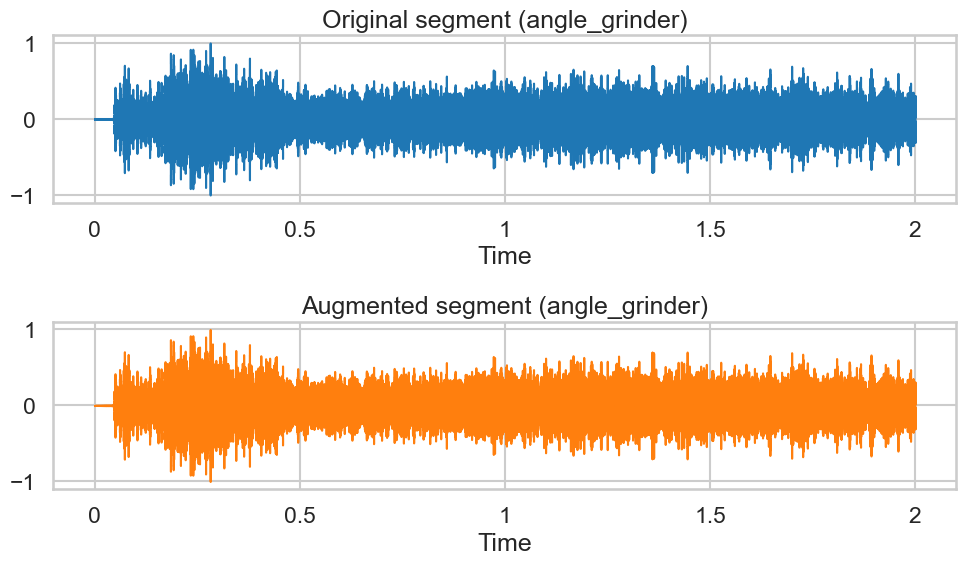


Loading: /Users/harryirving/Development/projects/ai-ml/BikeAIv3/data/raw/background_noise/chunk_001.wav


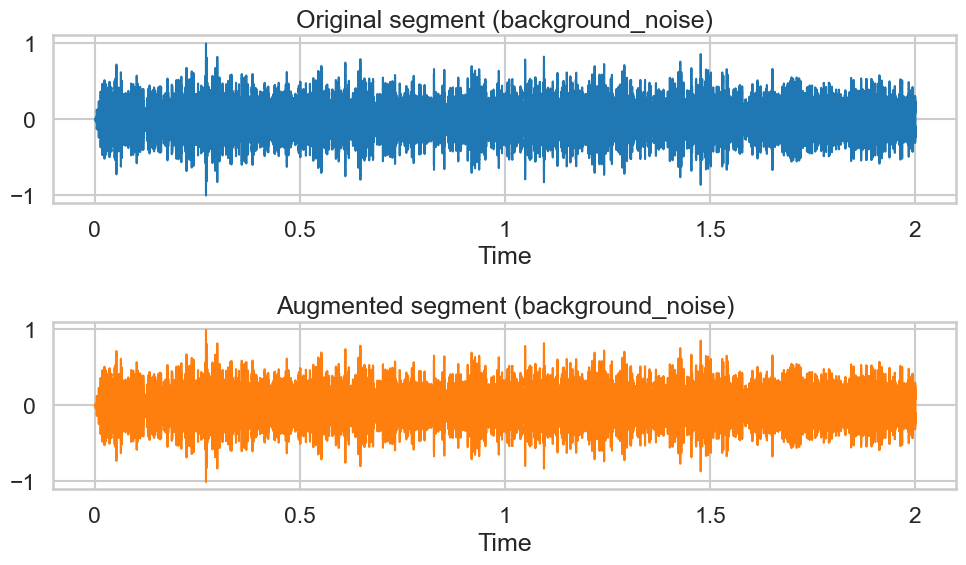


Loading: /Users/harryirving/Development/projects/ai-ml/BikeAIv3/data/raw/power_tools/air_powertool-35837.wav


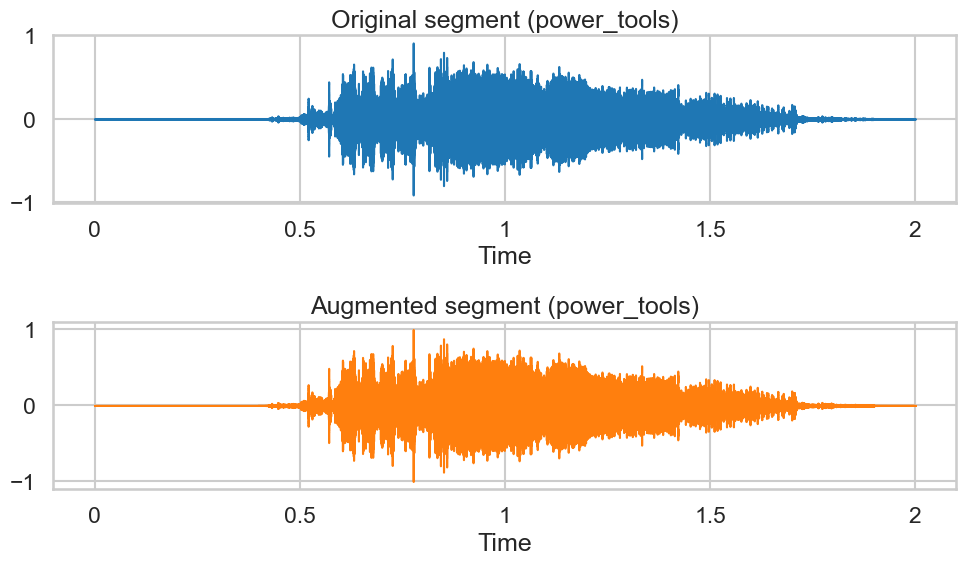


✓ Augmentation helpers defined and demo complete.


In [41]:
import random
import librosa
import librosa.display
import scipy.signal

# Pull augmentation and timing params
tcfg = cfg.get('training', {})
dcfg = cfg.get('config', {})
cfg_classical = tcfg.get('classical', {})
cfg_neural = tcfg.get('neural', {})
cfg_aug = tcfg.get('augmentation', {})

# Extract config params
sr = int(dcfg.get('sample_rate', 22050))
duration = float(dcfg.get('duration_s', 2.0))
normalize_method = dcfg.get('normalize_method', 'peak')
highpass_cutoff = float(dcfg.get('highpass_cutoff_hz', 80))

# Define helper functions
def normalize_audio(y, normalize_method='peak'):
    if normalize_method == 'peak':
        return y / (np.abs(y).max() + 1e-7)
    elif normalize_method == 'rms':
        return y / (np.sqrt(np.mean(y**2)) + 1e-7)
    return y

def apply_highpass(y, sr, cutoff_hz=80):
    sos = scipy.signal.butter(4, cutoff_hz, 'hp', fs=sr, output='sos')
    return scipy.signal.sosfilt(sos, y)

def segment_audio(y, sr, duration_s, overlap=0.0):
    frame_len = int(sr * duration_s)
    step = int(frame_len * (1 - overlap))
    segs = []
    for start in range(0, len(y) - frame_len + 1, step):
        segs.append(y[start:start+frame_len])
    if len(segs) == 0 and len(y) > 0:
        padded = np.pad(y, (0, max(0, frame_len - len(y))), 'constant')
        segs.append(padded[:frame_len])
    return segs

def fix_length_and_norm(y, sr, duration_s, normalize_method):
    segs = segment_audio(y, sr, duration_s, overlap=0.0)
    y_fixed = segs[0] if segs else y
    return normalize_audio(y_fixed, normalize_method)

def aug_once(y, sr, duration_s, normalize_method, cfg_aug):
    out = y.astype(np.float32).copy()

    # Gaussian noise
    g = cfg_aug.get('gaussian_noise', {})
    if g.get('enabled', False) and random.random() < float(g.get('prob', 0.0)):
        amp = np.random.uniform(float(g.get('min_amplitude', 0.001)),
                                float(g.get('max_amplitude', 0.015)))
        out = (out + np.random.normal(0, amp, size=out.shape).astype(np.float32))

    # Time stretch
    ts = cfg_aug.get('time_stretch', {})
    if ts.get('enabled', False) and random.random() < float(ts.get('prob', 0.0)):
        rate = np.random.uniform(float(ts.get('min_rate', 0.9)),
                                 float(ts.get('max_rate', 1.1)))
        out = librosa.effects.time_stretch(out, rate=rate)
        out = fix_length_and_norm(out, sr, duration_s, normalize_method)

    # Pitch shift
    ps = cfg_aug.get('pitch_shift', {})
    if ps.get('enabled', False) and random.random() < float(ps.get('prob', 0.0)):
        semi = np.random.uniform(float(ps.get('min_semitones', -2)),
                                 float(ps.get('max_semitones', 2)))
        out = librosa.effects.pitch_shift(out, sr=sr, n_steps=semi)

    # Time shift
    sh = cfg_aug.get('time_shift', {})
    if sh.get('enabled', False) and random.random() < float(sh.get('prob', 0.0)):
        frac = np.random.uniform(float(sh.get('min_fraction', -0.3)),
                                 float(sh.get('max_fraction', 0.3)))
        out = np.roll(out, int(len(out) * frac))

    # Gain
    gn = cfg_aug.get('gain', {})
    if gn.get('enabled', False) and random.random() < float(gn.get('prob', 0.0)):
        db = np.random.uniform(float(gn.get('min_gain_db', -6)),
                               float(gn.get('max_gain_db', 6)))
        out = out * (10 ** (db / 20.0))

    # Final enforcement
    out = fix_length_and_norm(out, sr, duration_s, normalize_method)
    return out.astype(np.float32)

# ===== POPULATE EXAMPLES FROM RAW DATA =====
RAW_DATA_DIR = ROOT / 'data' / 'raw'
examples = {}

for c in classes:
    class_dir = RAW_DATA_DIR / c
    if class_dir.exists():
        files = sorted(list(class_dir.glob('*.wav')) + list(class_dir.glob('*.mp3')) + list(class_dir.glob('*.flac')))
        examples[c] = files
        print(f"{c}: {len(files)} files")
    else:
        examples[c] = []
        print(f"{c}: directory not found")

print("\n=== Augmentation Demo ===")
for c in classes:
    lst = examples.get(c, [])
    if not lst:
        print(f"No audio files for {c}")
        continue
    
    p = lst[0]
    print(f"\nLoading: {p}")
    y, _ = librosa.load(str(p), sr=sr, mono=True)
    y = normalize_audio(apply_highpass(y, sr, highpass_cutoff), normalize_method)
    seg = segment_audio(y, sr, duration, overlap=0.0)[0]
    aug_seg = aug_once(seg, sr, duration, normalize_method, cfg_aug)

    fig, ax = plt.subplots(2, 1, figsize=(10, 6))
    librosa.display.waveshow(seg, sr=sr, ax=ax[0], color="C0")
    ax[0].set_title(f"Original segment ({c})")
    librosa.display.waveshow(aug_seg, sr=sr, ax=ax[1], color="C1")
    ax[1].set_title(f"Augmented segment ({c})")
    plt.tight_layout()
    plt.show()

print("\n✓ Augmentation helpers defined and demo complete.")



## Train MobileNetV2 (two-stage)

In [43]:
# Ensure single channel
if X_train.shape[-1] != 1:
    print(f"Converting {X_train.shape[-1]} channels to 1...")
    X_train = np.mean(X_train, axis=-1, keepdims=True).astype(np.float32)
    X_val = np.mean(X_val, axis=-1, keepdims=True).astype(np.float32)
    X_test = np.mean(X_test, axis=-1, keepdims=True).astype(np.float32)

print("After squeeze - X_train shape:", X_train.shape)
input_shape = X_train.shape[1:]
print("Updated input_shape:", input_shape)


mobilenet = load_mobilenet_v2(input_shape=input_shape, num_classes=num_classes)
mobilenet.trainable = False
mobilenet.compile(optimizer=keras.optimizers.Adam(lr_init), loss='categorical_crossentropy', metrics=['accuracy'])
hist_mb1 = mobilenet.fit(X_train, y_train_oh, validation_data=(X_val, y_val_oh), epochs=15, batch_size=batch_size, callbacks=[early], verbose=1)
unfreeze_layers(mobilenet, from_layer=-50)
mobilenet.compile(optimizer=keras.optimizers.Adam(lr_fine), loss='categorical_crossentropy', metrics=['accuracy'])
hist_mb2 = mobilenet.fit(X_train, y_train_oh, validation_data=(X_val, y_val_oh), epochs=25, batch_size=batch_size, callbacks=[early], verbose=1)


After squeeze - X_train shape: (9270, 64, 101, 1)
Updated input_shape: (64, 101, 1)
Epoch 1/15
290/290 ━━━━━━━━━━━━━━━━━━━━ 71s 127ms/step - accuracy: 0.3330 - loss: 1.5229 - val_accuracy: 0.3365 - val_loss: 1.2093
Epoch 2/15
290/290 ━━━━━━━━━━━━━━━━━━━━ 33s 114ms/step - accuracy: 0.3188 - loss: 1.5244 - val_accuracy: 0.3365 - val_loss: 1.2093
Epoch 3/15
290/290 ━━━━━━━━━━━━━━━━━━━━ 34s 118ms/step - accuracy: 0.3358 - loss: 1.5056 - val_accuracy: 0.3365 - val_loss: 1.2093
Epoch 4/15
290/290 ━━━━━━━━━━━━━━━━━━━━ 33s 113ms/step - accuracy: 0.3214 - loss: 1.5329 - val_accuracy: 0.3365 - val_loss: 1.2093
Epoch 5/15
290/290 ━━━━━━━━━━━━━━━━━━━━ 33s 113ms/step - accuracy: 0.3305 - loss: 1.5128 - val_accuracy: 0.3365 - val_loss: 1.2093
Epoch 6/15
290/290 ━━━━━━━━━━━━━━━━━━━━ 33s 114ms/step - accuracy: 0.3273 - loss: 1.5147 - val_accuracy: 0.3365 - val_loss: 1.2093
Epoch 7/15
290/290 ━━━━━━━━━━━━━━━━━━━━ 33s 113ms/step - accuracy: 0.3204 - loss: 1.5256 - val_accuracy: 0.3365 - val_loss: 1.2093

## Evaluate on test

69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step
                  precision    recall  f1-score   support

   angle_grinder       0.50      0.89      0.64       437
background_noise       0.82      0.92      0.87      1015
     power_tools       0.76      0.30      0.43       749

        accuracy                           0.70      2201
       macro avg       0.69      0.70      0.65      2201
    weighted avg       0.74      0.70      0.67      2201



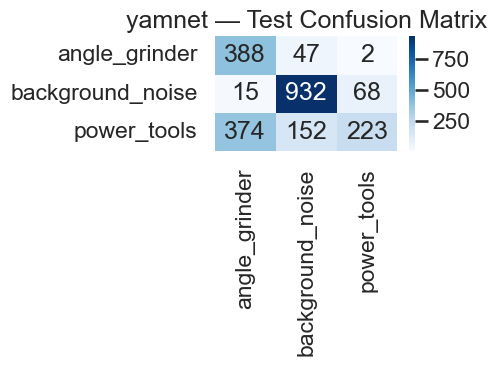

69/69 ━━━━━━━━━━━━━━━━━━━━ 10s 120ms/step
                  precision    recall  f1-score   support

   angle_grinder       0.25      0.05      0.08       437
background_noise       0.10      0.00      0.01      1015
     power_tools       0.34      0.93      0.49       749

        accuracy                           0.33      2201
       macro avg       0.23      0.33      0.19      2201
    weighted avg       0.21      0.33      0.19      2201



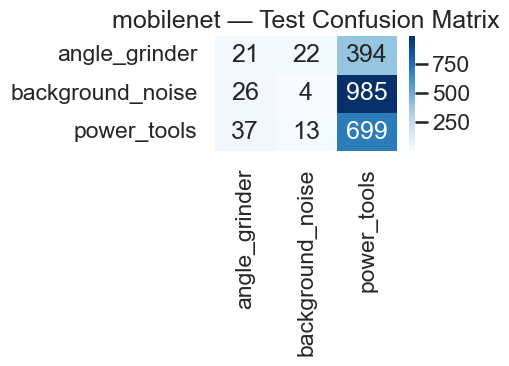

In [44]:
for name, model in [('yamnet', yamnet), ('mobilenet', mobilenet)]:
    y_pred = np.argmax(model.predict(X_test, batch_size=batch_size), axis=1)
    print(classification_report(y_test, y_pred, target_names=classes))
    cm = confusion_matrix(y_test, y_pred, labels=list(range(num_classes)))
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
    plt.title(f'{name} — Test Confusion Matrix')
    plt.tight_layout(); plt.savefig(PLOTS_DIR/f'{name}_ft_test_confusion.png', dpi=150); plt.show()
    report = classification_report(y_test, y_pred, target_names=classes, output_dict=True)
    with open(EVALS_DIR/f'{name}_ft_test_report.json','w') as f: json.dump(report, f, indent=2)
